### R7-CNN-Plant Seeding Classification Project

### Objective :
Classify an image of seedling into one the following 12 different seedling classes.

1. Black-grass
2. Charlock
3. Cleavers
4. Common Chickweed
5. Common wheat
6. Fat Hen
7. Loose Silky-bent
8. Maize
9. Scentless Mayweed
10. Shepherds Purse
11. Small-flowered Cranesbill
12. Sugar beet


The points distribution for this case is as follows:

1. Read the images and generate the train and test dataset (10 points)
2. Divide the data set into Train and validation data sets
3. Initialize & build the model (20 points)
4. Optimize the model (16 points)
5. Predict the accuracy for both train and validation data (14 points)

In [1]:
# import numpy and pandas library
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


Using TensorFlow backend.


In [0]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [0]:
import warnings 
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
filePath="/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/plant-seedlings-classification.zip"

In [0]:
!unzip -q "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/plant-seedlings-classification.zip" -d "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data"

In [0]:
#Unzip Train Data
!unzip -q "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data/train.zip" -d "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data"

In [0]:
!unzip -q "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data/test.zip" -d "/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data"

### 1. Read the images and generate the train and test dataset (10 points)

In [0]:
trainDataPath="/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data/train"
testDataPath="/content/drive/My Drive/AIML/NLP/plant-seedlings-classification/Data/test"

In [0]:
import os
from glob import glob
import cv2

In [0]:
lblDictionary = {'Loose Silky-bent':0, 'Charlock':1, 'Sugar beet':2, 'Small-flowered Cranesbill':3,
             'Common Chickweed':4, 'Common wheat':5, 'Maize':6, 'Cleavers':7, 'Scentless Mayweed':8,
             'Fat Hen':9, 'Black-grass':10, 'Shepherds Purse':11}

In [0]:
def getLabelClassFromFolderName(path):
  lbl_Dict=dict()
  i=0
  for class_folder_name in os.listdir(path):
    lbl_Dict[class_folder_name]=i
    i=i+1
  
  return lbl_Dict
    
  

In [0]:
def getImageDataFromLabelFolder(path,label_Class_Dictionary=None,img_w=128,img_h=128,isTrain_Data=False):
  images = []
  classes=[]
  
  if(isTrain_Data):
    for class_folder_name in os.listdir(path):
        class_folder_path = os.path.join(path, class_folder_name)
        class_label = class_folder_name
    
        for image_path in glob(os.path.join(class_folder_path, "*.png")):
            temp_img=tf.keras.preprocessing.image.load_img(image_path,target_size=(img_w,img_h))
            temp_img = tf.keras.preprocessing.image.img_to_array(temp_img)
            images.append(temp_img)
            classes.append(label_Class_Dictionary[class_label])
        
    classes = np.array(classes)
  else:
    
     for image_path in glob(os.path.join(path, "*.png")):
        test_img=tf.keras.preprocessing.image.load_img(image_path,target_size=(img_w,img_h))
        test_img = tf.keras.preprocessing.image.img_to_array(test_img)
        images.append(test_img)
        
      
  images = np.array(images)
  
  if(isTrain_Data):
    return images, classes
  else:
    return images
  

In [20]:
#Get Labels name  as dictionary format which help for modeling.
#Here Label name will be get it from train data each sub-folder name
lbl_Class=getLabelClassFromFolderName(trainDataPath)
print("Label Classes : \n {0}".format(lbl_Class))

Label Classes : 
 {'Fat Hen': 0, 'Small-flowered Cranesbill': 1, 'Cleavers': 2, 'Black-grass': 3, 'Sugar beet': 4, 'Shepherds Purse': 5, 'Charlock': 6, 'Loose Silky-bent': 7, 'Scentless Mayweed': 8, 'Maize': 9, 'Common Chickweed': 10, 'Common wheat': 11}


In [0]:
X,y=getImageDataFromLabelFolder(trainDataPath,lbl_Class,isTrain_Data=True)

In [22]:
X.shape

(4750, 128, 128, 3)

In [23]:
y.shape

(4750,)

In [0]:
X_test=getImageDataFromLabelFolder(testDataPath)

In [25]:
X_test.shape

(794, 128, 128, 3)

### Divide the data set into Train and validation data sets

1. training set : 70%
2. validation set: 30%

In [0]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=50)

In [52]:
print("Training Set",X_train.shape )
print("Validation Set",X_val.shape )
print("Test Set",X_test.shape )

Training Set (3325, 128, 128, 3)
Validation Set (1425, 128, 128, 3)
Test Set (794, 128, 128, 3)


### Convert train and validation data labels to one hot vectors

In [0]:
num_classes = 12 # No. of unique Label in the dataset (From 1 to 10)
# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [54]:
print(y_train.shape)
print('First 5 examples now are: \n', y_train[0:5])

(3325, 12)
First 5 examples now are: 
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


### Normalize the Train, Test and Validation image data from 0-255 to 0-1

In [0]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_val = X_val.astype('float32') / 255

### Initialize & build the model (20 points)

In [0]:
from keras.layers import Dense

In [0]:
#Initialize model, reshape & normalize data
model1 = tf.keras.models.Sequential()

In [0]:
model1.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,  activation='relu', input_shape=(128,128,3)))
#model1.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,  activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model1.add(tf.keras.layers.Dropout(0.2))

In [0]:
model1.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,  activation='relu', input_shape=(128,128,3)))
#model1.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,  activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model1.add(tf.keras.layers.Dropout(0.1))
model1.add(tf.keras.layers.Flatten())

In [0]:
model1.add(tf.keras.layers.Dense(256, activation='relu'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(tf.keras.layers.Dropout(0.5))
model1.add(tf.keras.layers.Dense(256, activation='relu'))
model1.add(tf.keras.layers.BatchNormalization())
model1.add(tf.keras.layers.Dropout(0.5))

In [0]:
model1.add(tf.keras.layers.Dense(64, activation='relu'))
model1.add(tf.keras.layers.Dense(64, activation='relu'))
model1.add(tf.keras.layers.Dense(12, activation='softmax'))

In [0]:
# compile model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [71]:
# Fit the model1 with 30 epochs and batch size 128 for train and validation data
m1_history=model1.fit(X_train, y_train, 
          validation_data=(X_val, y_val), 
          epochs=30,
          batch_size=128)

Train on 3325 samples, validate on 1425 samples
Epoch 1/30
3325/3325 [==============================] - 11s 3ms/sample - loss: 2.5659 - acc: 0.1326 - val_loss: 3.0220 - val_acc: 0.0933
Epoch 2/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 2.1561 - acc: 0.2812 - val_loss: 2.2470 - val_acc: 0.3032
Epoch 3/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 1.6915 - acc: 0.4364 - val_loss: 2.2132 - val_acc: 0.2498
Epoch 4/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 1.4105 - acc: 0.5173 - val_loss: 2.2334 - val_acc: 0.1965
Epoch 5/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 1.2335 - acc: 0.5738 - val_loss: 1.5606 - val_acc: 0.4646
Epoch 6/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 1.1231 - acc: 0.6078 - val_loss: 1.9629 - val_acc: 0.3158
Epoch 7/30
3325/3325 [==============================] - 6s 2ms/sample - loss: 1.0387 - acc: 0.6355 - val_loss: 1.7645 - val_acc: 0.3439

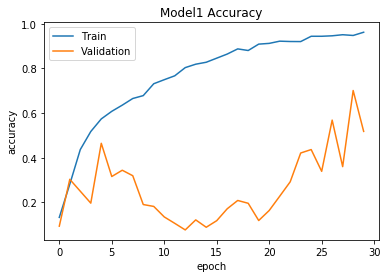

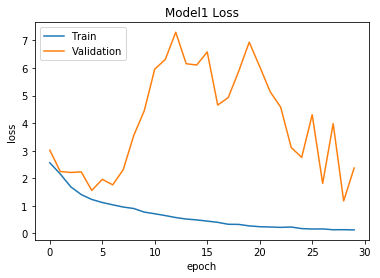

In [72]:
# summarize history for accuracy
plt.plot(m1_history.history['acc'])
plt.plot(m1_history.history['val_acc'])
plt.title('Model1 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m1_history.history['loss'])
plt.plot(m1_history.history['val_loss'])
plt.title('Model1 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Summary Model 1:

Model 1 is highly over-fit. This not a good model.Lets try to optimize and will improve model performance

In [73]:
model1.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 126, 126, 64)      1792      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 63, 63, 64)        0         
_________________________________________________________________
dropout_6 (Dropout)          (None, 63, 63, 64)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 61, 61, 64)        36928     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 30, 30, 64)        0         
_________________________________________________________________
dropout_7 (Dropout)          (None, 30, 30, 64)        0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 57600)            

### Optimize the model (16 points)

#### 1. Data Augmentation - Optimization technique

In [0]:
# construct the training image generator for data augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(rotation_range=20, zoom_range=0.15,
	width_shift_range=0.2, height_shift_range=0.2, shear_range=0.15,
	horizontal_flip=True)

In [0]:
datagen.fit(X_train)
datagen.fit(X_val)

In [0]:
#Create train and test generator
batchsize = 64
train_generator = datagen.flow(X_train, y_train, batch_size=batchsize) #batchsize can be changed
test_generator = datagen.flow(X_val, y_val, batch_size=batchsize)

In [0]:
#Initialize model, reshape & normalize data
model2 = tf.keras.models.Sequential()

In [0]:
model2.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,  activation='relu', input_shape=(128,128,3)))
#model1.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,  activation='relu'))
model2.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model2.add(tf.keras.layers.Dropout(0.2))

In [0]:
#Add Flatten Layer
model2.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model2.add(tf.keras.layers.Dense(64, activation='relu'))
#Add - Dense Layer - 128 Nurons with Relu
model2.add(tf.keras.layers.Dense(64, activation='relu'))
#Add - Dense Layer/output layer - 12 Nurons with Softmax
model2.add(tf.keras.layers.Dense(12, activation='softmax'))

In [0]:
# compile model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [81]:
# Fit the model1 with 30 epochs and batch size 128 for train and validation data
m2_history=model2.fit_generator(train_generator, 
          validation_data=test_generator, 
          epochs=30)

Epoch 1/30
52/52 [==============================] - 22s 424ms/step - loss: 2.6513 - acc: 0.1720 - val_loss: 2.3708 - val_acc: 0.2435
Epoch 2/30
52/52 [==============================] - 19s 363ms/step - loss: 2.2658 - acc: 0.2677 - val_loss: 2.0876 - val_acc: 0.2898
Epoch 3/30
52/52 [==============================] - 19s 361ms/step - loss: 1.9730 - acc: 0.3224 - val_loss: 1.8670 - val_acc: 0.3179
Epoch 4/30
52/52 [==============================] - 19s 373ms/step - loss: 1.8711 - acc: 0.3320 - val_loss: 1.7630 - val_acc: 0.3537
Epoch 5/30
52/52 [==============================] - 19s 369ms/step - loss: 1.7802 - acc: 0.3717 - val_loss: 1.7175 - val_acc: 0.4063
Epoch 6/30
52/52 [==============================] - 19s 364ms/step - loss: 1.7542 - acc: 0.3792 - val_loss: 1.7024 - val_acc: 0.4077
Epoch 7/30
52/52 [==============================] - 19s 365ms/step - loss: 1.6668 - acc: 0.4075 - val_loss: 1.6409 - val_acc: 0.4112
Epoch 8/30
52/52 [==============================] - 19s 369ms/step - 

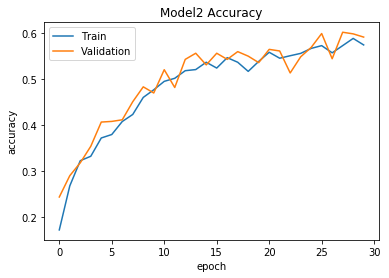

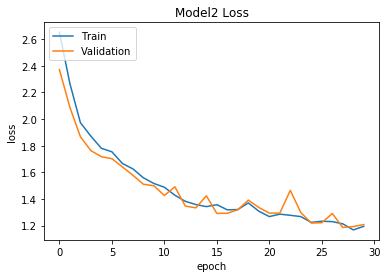

In [82]:
# summarize history for accuracy
plt.plot(m2_history.history['acc'])
plt.plot(m2_history.history['val_acc'])
plt.title('Model2 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m2_history.history['loss'])
plt.plot(m2_history.history['val_loss'])
plt.title('Model2 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Predict the accuracy for both train and validation data (14 points)

In [83]:
model_Train_result=model2.evaluate(X_train,y_train,verbose=1)


3325/3325 [==============================] - 2s 479us/sample - loss: 1.0607 - acc: 0.6232


In [84]:
model_val_result=model2.evaluate(X_val,y_val,verbose=1)

1425/1425 [==============================] - 1s 450us/sample - loss: 1.0975 - acc: 0.6309


In [0]:
model_Result=pd.DataFrame(index=["Data Type","Accuracy","Loss"])
model_Result["TrainData"]=["Train Data",("%0.2f" % ((model_Train_result[1]*100))),("%0.2f" % ((model_Train_result[0])))]
model_Result["ValData"]=["Validation Data",("%0.2f" % ((model_val_result[1]*100))),("%0.2f" % ((model_val_result[0])))]


In [86]:
model_Result

,TrainData,ValData
Data Type,Train Data,Validation Data
Accuracy,62.32,63.09
Loss,1.06,1.10
